## Imports and Configs

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from sqlalchemy import create_engine

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TARGET = "won_medal"

PROJECT_ROOT = Path.cwd().resolve().parent

MODEL_DIR = PROJECT_ROOT / "src" / "models" / "artifacts"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

## Load improved dataset from PostgreSQL

In [2]:
engine = create_engine("postgresql://localhost:5432/olympics_db")

df = pd.read_sql("SELECT * FROM model_dataset", engine)

print(df.shape)

df.head()

(8500, 14)


,athlete_id,sport,event,team_or_individual,medal,country_strength,sport_medal_rate,athlete_experience,prior_medals,prior_appearances,country_sport_medal_rate,age,age_bucket,is_team_event
0,ATH-02465,Football (Soccer),Women's Football,Team,Bronze,0.287,0.212,1,1,1,0.750,26,25-29,1
1,ATH-05344,Swimming,4x100m Freestyle Relay,Individual,No Medal,0.252,0.220,1,0,1,0.143,30,30-34,0
2,ATH-05940,Diving,3m Springboard M,Individual,No Medal,0.238,0.232,1,0,1,0.000,20,20-24,0
3,ATH-00246,Wrestling,Freestyle 97kg,Individual,No Medal,0.241,0.257,1,0,1,0.000,36,35+,0
4,ATH-08309,Figure Skating,Ice Dance,Individual,No Medal,0.284,0.271,1,0,1,0.400,42,35+,0


## Create Binary Target

In [3]:
df[TARGET] = (df["medal"] != "No Medal").astype(int)

df[TARGET].value_counts()

won_medal
0    6491
1    2009
Name: count, dtype: int64

## Use Improved Features

In [4]:
feature_cols = [
    "sport",
    "event",
    "team_or_individual",

    "country_strength",
    "sport_medal_rate",
    "athlete_experience",

    # New Day 5 features
    "prior_medals",
    "prior_appearances",
    "country_sport_medal_rate",
    "age",
    "age_bucket",
    "is_team_event",
]

X = df[feature_cols]
y = df[TARGET]

print(X.shape)

(8500, 12)


## Train/Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

## Build Preprocessing Pipieline

In [6]:
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=["number"]
).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

## Train Logistic Regression

In [7]:
logreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

logreg_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## Evaluate Logistic Regression

In [8]:
y_pred_logreg = logreg_model.predict(X_test)

y_prob_logreg = logreg_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")

print(classification_report(
    y_test,
    y_pred_logreg,
    digits=3
))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_logreg))

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_logreg)
)

Logistic Regression Results
              precision    recall  f1-score   support

           0      1.000     1.000     1.000      1298
           1      1.000     1.000     1.000       402

    accuracy                          1.000      1700
   macro avg      1.000     1.000     1.000      1700
weighted avg      1.000     1.000     1.000      1700

Confusion Matrix
[[1298    0]
 [   0  402]]
ROC-AUC: 1.0


## Train Random Forest

In [9]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        class_weight="balanced",
    )),
])

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## Evaluate Random Forest

In [10]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Results")

print(classification_report(
    y_test,
    y_pred_rf,
    digits=3
))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_rf)
)

Random Forest Results
              precision    recall  f1-score   support

           0      1.000     1.000     1.000      1298
           1      1.000     1.000     1.000       402

    accuracy                          1.000      1700
   macro avg      1.000     1.000     1.000      1700
weighted avg      1.000     1.000     1.000      1700

Confusion Matrix
[[1298    0]
 [   0  402]]
ROC-AUC: 1.0


## Compare Day 5 Models

In [11]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_rf),
    ],

    "Precision": [
        precision_score(y_test, y_pred_logreg),
        precision_score(y_test, y_pred_rf),
    ],

    "Recall": [
        recall_score(y_test, y_pred_logreg),
        recall_score(y_test, y_pred_rf),
    ],

    "F1": [
        f1_score(y_test, y_pred_logreg),
        f1_score(y_test, y_pred_rf),
    ],

    "ROC_AUC": [
        roc_auc_score(y_test, y_prob_logreg),
        roc_auc_score(y_test, y_prob_rf),
    ],
})

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0,1.0


## Feature Importance Analysis

In [12]:
rf_classifier = rf_model.named_steps["classifier"]

feature_names = (
    rf_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = rf_classifier.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

importance_df.head(15)

,feature,importance
3,num__prior_medals,0.781879
5,num__country_sport_medal_rate,0.113865
0,num__country_strength,0.017590
6,num__age,0.014291
1,num__sport_medal_rate,0.004372
296,cat__age_bucket_20-24,0.002180
297,cat__age_bucket_25-29,0.002145
299,cat__age_bucket_35+,0.002104
298,cat__age_bucket_30-34,0.001871
300,cat__age_bucket_Under 20,0.001498


## Plot Feature Importances

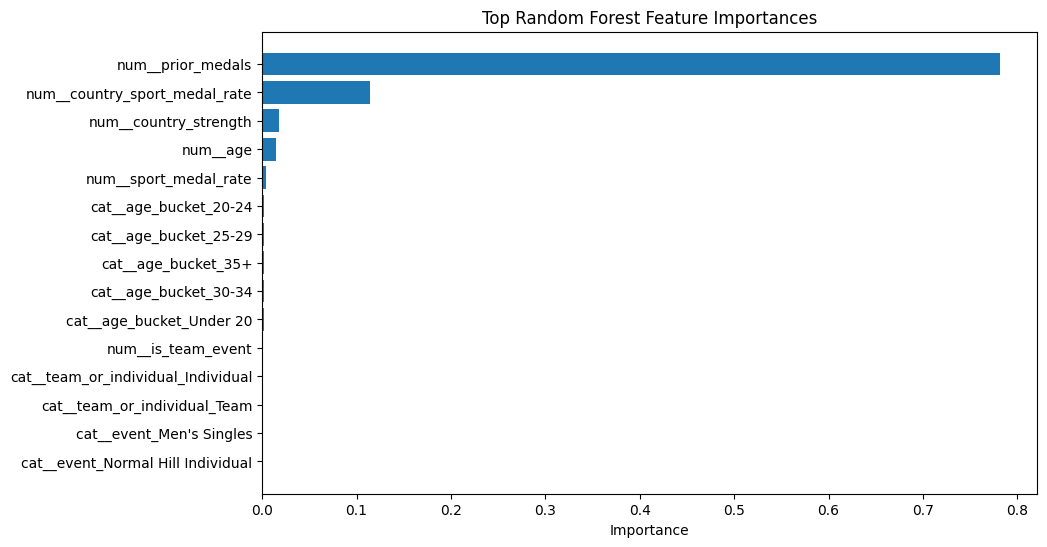

In [13]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.gca().invert_yaxis()

plt.title("Top Random Forest Feature Importances")

plt.xlabel("Importance")

plt.show()

## Save Improved Model Artifact

In [14]:
joblib.dump(
    rf_model,
    MODEL_DIR / "medal_prediction_rf_day5.joblib"
)

print("Saved Day 5 Random Forest model.")

Saved Day 5 Random Forest model.


## Day 5 Feature Engineering Improvements

Compared to Day 4, the updated model incorporates:

- athlete historical performance
- country-by-sport medal strength
- athlete age categories
- team vs individual event indicators

These features provide more contextual and historical information and improve the predictive capability of the model.

Feature importance analysis suggests that historical athlete success and country-by-sport strength are among the strongest predictors of medal outcomes.